# Imports and Data loading

<Figure size 640x480 with 0 Axes>

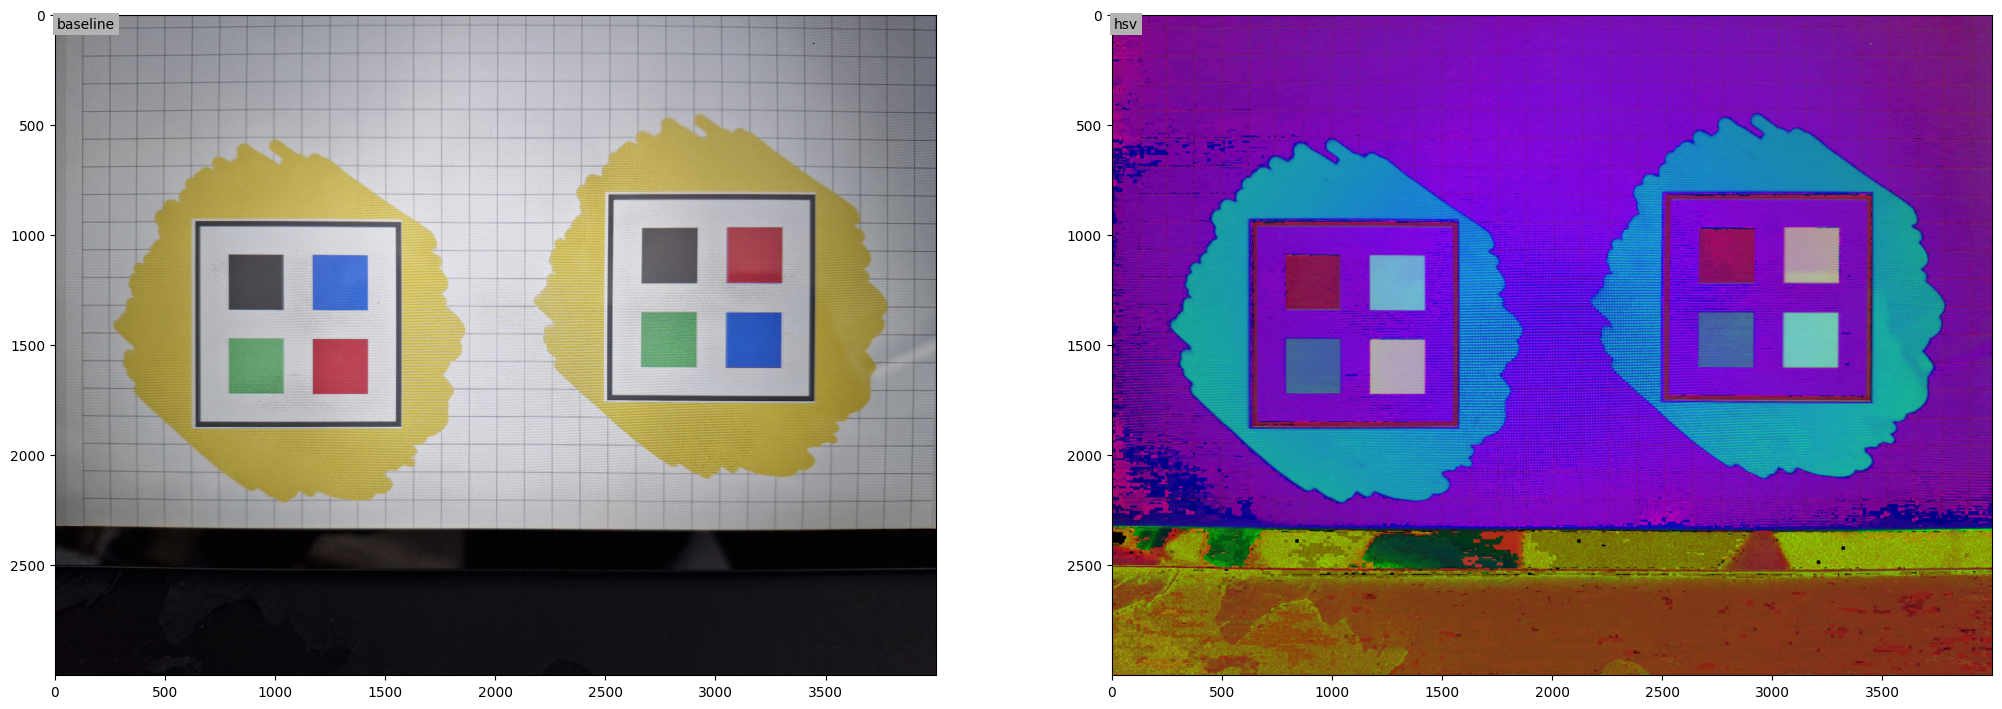

In [1]:
import math

import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

src_path = './data/'

baseline_path = src_path + 'baseline.jpg'

baseline_img = cv.imread(baseline_path)
baseline_img = cv.cvtColor(baseline_img, cv.COLOR_BGR2RGB)
hsv_img = cv.cvtColor(baseline_img, cv.COLOR_RGB2HSV)


def show_imgs(img_map):
    img_list = [img_data['img'] for img_data in img_map.values()]
    legend_list = [img_data['lgd'] for img_data in img_map.values()]
    
    plt.hsv()
    _, axs = plt.subplots(1, len(img_list), figsize=(25, 25))
    if len(img_list) == 1:
        axs = [axs]
    for i, img in enumerate(img_list):
        axs[i].imshow(img,cmap='gray')
        if legend_list != []:
            axs[i].text(
                10.0, 10.0, 
                legend_list[i],
                fontsize='medium',
                verticalalignment='top',
                bbox=dict(facecolor='0.7', edgecolor='none', pad=3.0)
            )
    
    plt.show()

img_map = {
    'baseline': {
        'img': baseline_img,
        'lgd': 'baseline'
    },
    'hsv': {
        'img': hsv_img,
        'lgd': 'hsv'
    },
}

show_imgs(img_map)

# Image preprocessing

## Separated color masking

<Figure size 640x480 with 0 Axes>

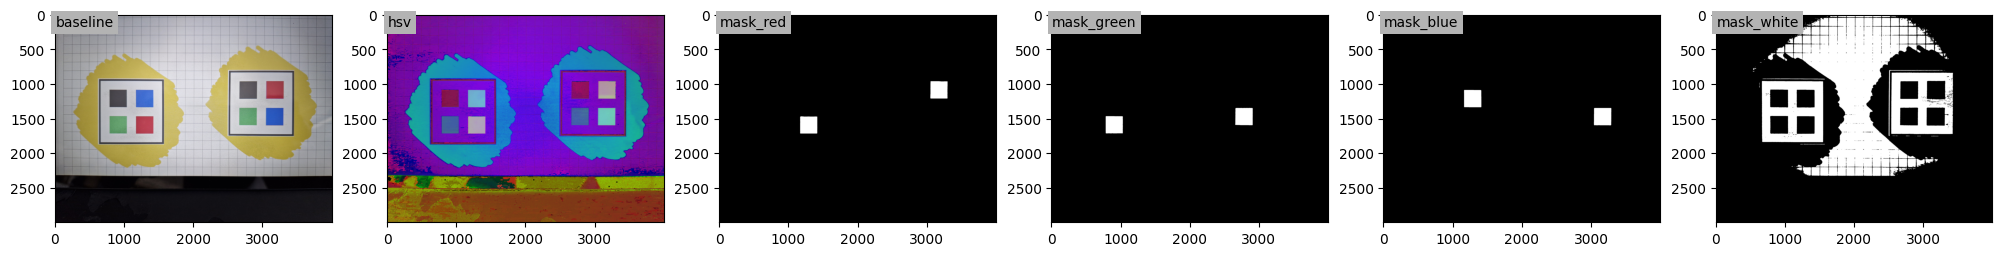

In [2]:
COLOR_LIMITS = {
    'red':{
        'min': (160,100,100),
        'max': (180, 255, 255)
    },
    'green':{
        'min': (30, 50, 100),
        'max': (80, 255, 255)
    },
    'blue':{
        'min': (80,100,100),
        'max': (130, 255, 255)
    },
    'white':{
        'min': (0,0,180),
        'max': (255, 25, 255)
    }

}

# Overlapping for testing
# COLOR_LIMITS = {
#     'red':{
#         'min': (160,100,100),
#         'max': (180, 255, 255)
#     },
#     'green':{
#         'min': (30, 50, 100),
#         'max': (130, 255, 255)
#     },
#     'blue':{
#         'min': (80,100,100),
#         'max': (130, 255, 255)
#     },
#     'white':{
#         'min': (0,0,180),
#         'max': (255, 25, 255)
#     }

# }

for color, limits in COLOR_LIMITS.items():
    
    mask = cv.inRange(img_map['hsv']['img'], limits['min'], limits['max'])
    mask = cv.medianBlur(mask, 7)
    mask = cv.medianBlur(mask, 7)
    
    # masked = cv.bitwise_and(img_map['baseline']['img'], img_map['baseline']['img'], mask= mask)
    img_tag = f"mask_{color}"
    img_map[img_tag] = {
        'img': mask,
        'lgd': img_tag
    }

show_imgs(img_map)

## Finding contours and centroids

<Figure size 640x480 with 0 Axes>

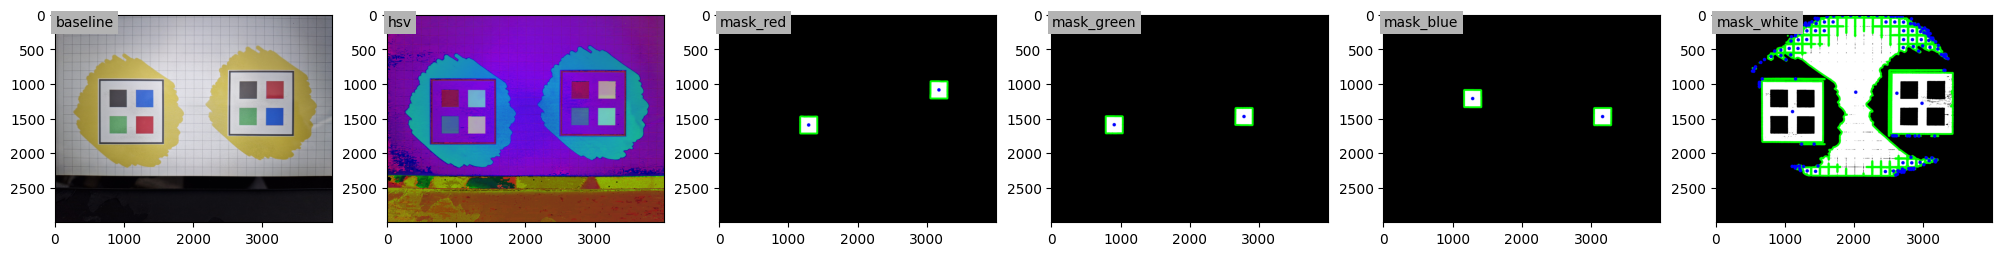

In [3]:
contour_map = {}

for color in ['red', 'green', 'blue', 'white']:
    img_tag = f"mask_{color}"
    mask = img_map[img_tag]['img']
    # Calculating external contours 
    contours, hierarchy = cv.findContours(
        image=mask, 
        mode=cv.RETR_EXTERNAL, 
        method=cv.CHAIN_APPROX_SIMPLE)

    gray2rgb_img = cv.cvtColor(mask,cv.COLOR_GRAY2RGB)
    
    contour_img = cv.drawContours(
        image=gray2rgb_img, 
        contours=contours, 
        contourIdx=-1, 
        color=(0, 255, 0), 
        thickness=25, 
        lineType=cv.LINE_AA
    )
    # Getting contour centroids
    centroids = []
    for i, contour in enumerate(contours):
        M = cv.moments(contour)

        # Checking if contour has area
        if M['m00'] != 0:
            cx = int(M['m10']/M['m00'])
            cy = int(M['m01']/M['m00'])
            
            # Area of contour
            weight = int(M['m00'])
            
            if weight >= 4:
                centroids.append([cx, cy, weight, i])

    # Marking all centroids
    for centroid in centroids:
        cv.circle(contour_img, (centroid[0], centroid[1]), 25, (0, 0, 255), -1)

    contour_map[color] = {
        'contours': contours,
        'hierarchy': hierarchy,
        'centroids': centroids,
    }
    img_map[img_tag]['img'] = contour_img
    
show_imgs(img_map)

# Applying Tracking Rules

<Figure size 640x480 with 0 Axes>

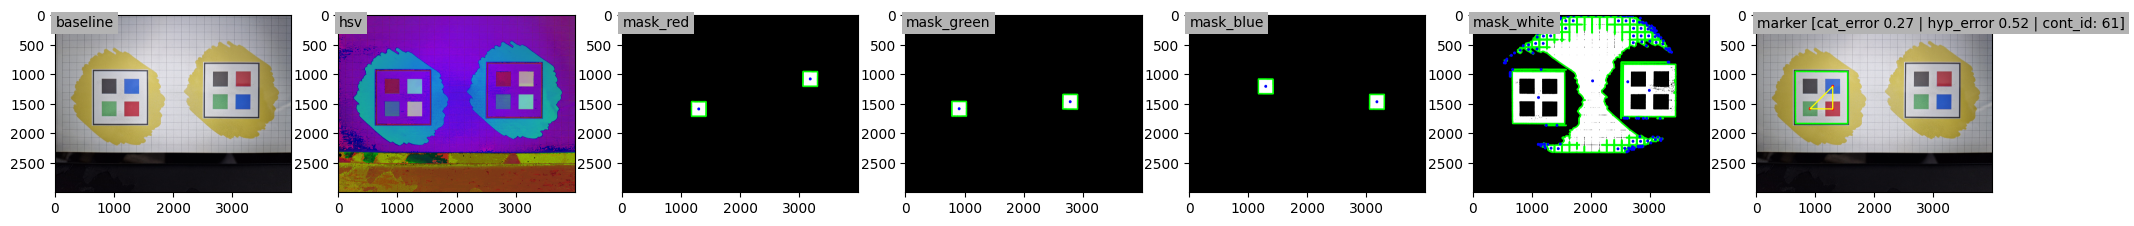

In [4]:


# Validating background contours, 
# i.e. white contours with at least one of each color contour inside
bkgd_contour_data = contour_map['white']
for bkgd_centroid in bkgd_contour_data['centroids']:
    contour_id = bkgd_centroid[-1]
    bkgd_contour = bkgd_contour_data['contours'][contour_id]

    inside_contours = {}
    all_colors = True
    is_marker = False
    for color in ['red', 'green', 'blue']:
        inside_contours[color] = {}
        inside_contours[color]['centroids'] = []
        for color_centroid in contour_map[color]['centroids']:
            # Point's distance to contour ( > 0: Indide | < 0: Outside | = 0: Over contour)
            relative_distance = cv.pointPolygonTest(
                contour= bkgd_contour, 
                pt= (color_centroid[0], color_centroid[1]), 
                measureDist= True
            )
            
            if relative_distance > 0:
                inside_contours[color]['centroids'].append(color_centroid)
        
        
        if len(inside_contours[color]['centroids']) > 0:
            # Getting main centroid from weighted average over contour areas
            inside_centroids = np.array(inside_contours[color]['centroids'])
            avg_centroid = [
                int(sum(inside_centroids[:,2]*inside_centroids[:,0])/sum(inside_centroids[:,2])),
                int(sum(inside_centroids[:,2]*inside_centroids[:,1])/sum(inside_centroids[:,2]))
            ]
            inside_contours[color]['center'] = avg_centroid
        
        # Missing a color in marker
        else:
            all_colors = False
        
    if all_colors:
        
        # Calculating Marker geometry errors
        ERROR_MARGIN = 0.03
        red_center = inside_contours['red']['center'][:2]
        green_center = inside_contours['green']['center'][:2]
        blue_center = inside_contours['blue']['center'][:2]
        
        red_green_dist = math.dist(red_center, green_center)
        red_blue_dist = math.dist(red_center, blue_center)
        green_blue_dist = math.dist(green_center, blue_center)
        
        avg_cathetus = (red_green_dist + red_blue_dist)/2
        avg_hypotenuse = math.sqrt(2*math.pow(avg_cathetus,2))
        
        cathetus_error = abs(red_green_dist - red_blue_dist)
        
        hypotenuse_cathetus_a_error = abs(green_blue_dist - math.sqrt(2)*red_blue_dist)
        hypotenuse_cathetus_b_error = abs(green_blue_dist - math.sqrt(2)*red_green_dist)
        
        hypotenuse_error = (hypotenuse_cathetus_a_error + hypotenuse_cathetus_b_error)/2
        
        # Geometry errors under error margin
        is_marker = (cathetus_error <= ERROR_MARGIN*avg_cathetus) and (hypotenuse_error <= ERROR_MARGIN*avg_hypotenuse)
        if is_marker:
            contour_img = cv.drawContours(
                image=img_map['baseline']['img'].copy(), 
                contours=bkgd_contour_data['contours'], 
                contourIdx=contour_id, 
                color=(0, 255, 0), 
                thickness=25, 
                lineType=cv.LINE_AA
            )
            
            for values in inside_contours.values():
                for centroid in values['centroids']:
                    cv.circle(contour_img, (centroid[0], centroid[1]), 25, (0, 0, 255), -1)
                    
                cv.circle(contour_img, values['center'], 25, (255, 0, 0), -1)
            
            center_R = inside_contours['red']['center']
            center_G = inside_contours['green']['center']
            center_B = inside_contours['blue']['center']
            
            
            cv.line(contour_img, center_G, center_B, (255, 255, 0), 20)
            cv.line(contour_img, center_G, center_R, (255, 255, 0), 20)
            cv.line(contour_img, center_R, center_B, (255, 255, 0), 20)
            
            img_tag = 'marker'
            img_lgd = f"marker [cat_error {(cathetus_error/avg_cathetus)*100:.2f} | hyp_error {(hypotenuse_error/avg_hypotenuse)*100:.2f} | cont_id: {contour_id}]"   
            img_map[img_tag] = {
            'img': contour_img,
            'lgd': img_lgd
            }

show_imgs(img_map)